# **Equazioni Differenziali Ordinarie (ODE) - Parte 1: metodi di Eulero**
Consideriamo l'evoluzione temporale di una quantità scalare $y=y(t)\in\mathbb{R}$, la cui dinamica è descritta da un problema di Cauchy della forma:
\begin{equation*}
\begin{cases}
y'(t)=f(t,y(t)) & t_0 \le t\le t_{N},\\ y(0)=y_{0}.
\end{cases}
\end{equation*}
</br>
Per poter risolvere numericamente il problema suddividiamo l'intervallo $I=[t_0,t_N]$ in $N$ sottointervalli con la stessa dimensione data da
</br></br>
\begin{equation*}
h= \dfrac{t_N-t_0}{N}
\end{equation*}
</br>
e definiamo gli istanti discreti $\{t_{0},t_{1},\dots,t_{N}\}$ in cui calcoleremo la soluzione approssimata come
</br></br>
\begin{equation*}
t_n=t_0+nh.
\end{equation*}
</br>
Lo scopo di un metodo numerico per l'equazioni differenziali ordinarie (ODE)  è quello di approssimare la dinamica di $y$ con una sequenza discreta 
$\{u_{0}=y_{0},u_{1},\dots,u_{N}\}$
tale per cui
\begin{equation*}
u_{n}\approx y(t_{n}).
\end{equation*}

## 1. Il metodo di Eulero in avanti </br>
L'idea del metodo di Eulero in avanti è quella di costruire una griglia temporale equispaziata di passo $h>0$ ed approssimare la soluzione del sistema secondo lo schema iterativo sottostante
</br> </br>
\begin{equation*}
\begin{cases}
u_{0}=y_{0}\\u_{n+1}=u_{n}+hf(t_{n},u_{n}) & n=0,\dots,N-1
\end{cases}
\end{equation*}
</br>
Tale schema è detto *esplicito* e ad un passo (*one-step*), in quanto, ad ogni passo temporale, la soluzione numerica $u_{n+1}$ dipende soltanto dalla soluzione al passo temporale precedente $u_{n}$.

<mark>**Esercizio 1**</mark></br></br>
Scrivere una funzione chiamata $\texttt{eulero\_avanti}$ che, dati $f$, $t_0$, $t_N$, $y_0$ ed $h$, implementi il metodo di Eulero in avanti, restituendo la griglia temporale $\mathbf{t}_h=[t_{0},\dots,t_{N}]$ e la sequenza approssimante $\mathbf{u}_h=[u_{0},\dots,u_{N}]$.

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
def eulero_avanti(f, t0, tN, y0, h):
    """Metodo di Eulero in avanti
    Input:
        f   (lambda function)               Funzione che rappresenta il termine di destra dell'ODE: f(t, y)                    
        t0  (float)                         Tempo iniziale
        tN  (float)                         Tempo finale
        y0  (float,list o numpy.ndarray)    Condizione iniziale: scalare.
        h   (float)                         Passo temporale

    Output:
        t_h   (numpy.ndarray)     Vettore degli istanti temporali (lunghezza N+1).
        u_h   (numpy.ndarray)     Soluzione discreta nei nodi temporali (lunghezza N+1).
    """

    # TODO: implementazione eulero in avanti 
   
    N=int((tN-t0)/h)
    t_h=np.zeros(N+1)
    u_h=np.zeros(N+1)
    t_h[0]=t0
    u_h[0]=y0

    for i in range(N): #oppure range(1:N+1)
        u_h[i+1]=u_h[i]+h*f(t_h[i],u_h[i])
        t_h[i+1]=t_h[i]+h
        
    return t_h, u_h

## 2. Il metodo di Eulero all'indietro </br>
In alternativa al metodo di Eulero "in avanti", esiste anche una sua versione "all'indietro", la quale si basa invece sul seguente schema iterativo
</br></br>
\begin{equation*}
\begin{cases}
u_{0}=y_{0}\\u_{n+1}=u_{n}+hf(t_{n+1},u_{n+1}) & n=0,\dots,N-1
\end{cases}
\end{equation*}
</br>
Tale schema è detto *implicito* e ad un passo (*one-step*), in quanto, ad ogni passo temporale, la soluzione numerica $u_{n+1}$ dipende dalla stessa incongita $u_{n+1}$, oltre che da $u_n$. Quindi, di volta in volta, bisognerà risolvere un'equazione non lineare
\begin{equation*}
z=u_n + h f(t_{n+1}, z)
\end{equation*}
nella variabile incognita $z$. La soluzione di tale equazione si può approssimare, ad esempio, con il metodo del punto fisso.
</br>
</br>
Si osservi che l'utilizzo di un metodo di punto fisso richiede che il modulo della derivata della funzione di iterazione utilizzata sia minore di uno; questa condizione è generalmente soddisfatta per $h$ sufficientemente piccolo.

<mark>**Esercizio 2**</mark></br></br>
Scrivere una funzione chiamata  $\texttt{eulero\_indietro}$ che, dati $f$, $t_0$, $t_N$, $y_0$ ed $h$, implementi il metodo di Eulero all'indietro, restituendo la griglia temporale $\mathbf{t}_h=[t_{0},\dots,t_{N}]$ e la sequenza approssimante $\mathbf{u}_h=[u_{0},\dots,u_{N}]$. Sfruttare il metodo $\texttt{puntofisso}$ che troviamo in $\texttt{utilis\_ODE.py}$

In [5]:
def puntofisso(phi, x0, nmax=100, toll=1.0e-6):
    """
    Metodo del punto fisso (fixed-point iteration).

    Trova il punto fisso dell'equazione x = phi(x) mediante iterazione funzionale.

    Input:
        phi (callable): Funzione di iterazione
        x0 (float): Punto di partenza
        nmax (int): Numero massimo di iterazioni (default: 100)
        toll (float): Tolleranza richiesta (default: 1e-6)

    Output:
        xvect (numpy.ndarray): Vettore delle iterate

    Nota:
        Il metodo converge se |φ'(x*)| < 1 in un intorno del punto fisso x*.
    """

    # Inizializzazione
    xvect = []
    xold = x0

    for nit in range(nmax):
        # Calcola il nuovo punto
        xnew = phi(xold)
        # Accumula nel vettore
        xvect.append(xnew)

        # Criterio di arresto e aggiornamento
        if abs(xnew - xold) < toll:
            break
        else:
            xold = xnew

    return np.array(xvect)

In [6]:
def eulero_indietro(f, t0, tN, y0, h):
    """Metodo di Eulero all'indietro
    Input:
        f   (lambda function)               Funzione che rappresenta il termine di destra dell'ODE: f(t, y)                    
        t0  (float)                         Tempo iniziale
        tN  (float)                         Tempo finale
        y0  (float,list o numpy.ndarray)    Condizione iniziale: scalare.
        h   (float)                         Passo temporale

    Output:
        t_h   (numpy.ndarray)     Vettore degli istanti temporali (lunghezza N+1).
        u_h   (numpy.ndarray)     Soluzione discreta nei nodi temporali (lunghezza N+1).
    """
    
    # inizializzazione 
    N=int((tN-t0)/h)
    t_h=np.zeros(N+1)
    u_h=np.zeros(N+1)
    t_h[0]=t0
    u_h[0]=y0

    # parametri per il punto fisso
    nmax_pf = 300
    toll_pf = 1e-5


    # TODO: implementazione eulero all'indietro 
    for i in range(N): #oppure range(1:N+1)
        t_h[i+1]=t_h[i]+h  #se non lo definisco prima della phi, nella phi dovrei scrivere non t_h[i+1], ma t_h[i]+h
        #devo utilizzare il metodo del punto fisso
        phi=lambda z: u_h[i]+h*f(t_h[i+1], z) #z sarebbe, nella formulazione di EI, u_h[N+1]
        u_pf=puntofisso(phi,u_h[i], nmax_pf, toll_pf)
        u_h[i+1]=u_pf[-1] #devo prendere l'ultimo valore della serie che restituisce il metodo di punto fisso
        
    return t_h, u_h
    

## 3. Applicazione a un caso esempio

Si consideri il problema di Cauchy
\begin{equation*}
\begin{cases}
\displaystyle
y'(t)=\frac{1}{1+t^2}-2y(t)^2 & 0\le t\le 10,\\ y(0)=0,
\end{cases}
\end{equation*}
la cui soluzione esatta è
\begin{equation*}
y(t)=\frac{t}{1+t^{2}}.
\end{equation*}


<mark>**Esercizio 3.1**</mark></br> Rappresentare graficamente la soluzione esatta nell'intervallo considerato.

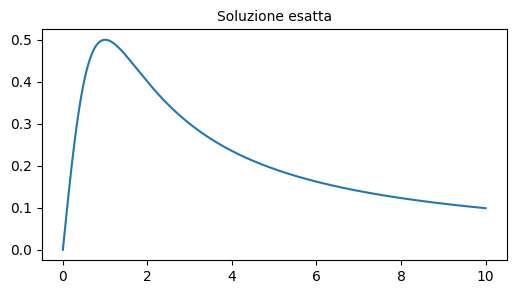

In [7]:
# Es. 3.1 - Plot soluzione esatta
# tempo iniziale e finale
t0, tN = 0, 10
# t per la rappresentazione grafica
tplot = np.linspace(t0, tN, 1000)
# soluzione esatta
yesatta = lambda t: t/(1.0+t**2)

plt.figure(figsize = (6,3))
plt.plot(tplot, yesatta(tplot))
plt.title("Soluzione esatta", fontsize = 10)
plt.show()

<mark>**Esercizio 3.2**</mark></br> Approssimare la soluzione del problema utilizzando il metodo di **Eulero in avanti**, prima con $h=0.2$  e poi con  $h=0.05$. Confrontare graficamente le soluzioni numeriche con la soluzione esatta;

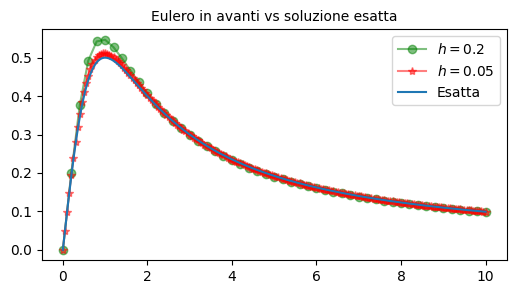

In [8]:
# Es. 3.2 - Eulero in avanti per h = 0.2, 0.05
# dato iniziale
t0,tN=0,10
y0 = 0
# funzione f del problema di cauchy che dipende dal tempo e dalla y
f = lambda t, y: 1.0/(1+t**2) - 2*y*y

t1, u1 = eulero_avanti(f, t0, tN, y0, h = 0.2)
t2, u2 = eulero_avanti(f, t0, tN, y0, h = 0.05)

plt.figure(figsize = (6,3))
plt.plot(t1, u1, '-o', label = '$h=0.2$', alpha = 0.5, color = 'green')
plt.plot(t2, u2, '-*', label = '$h=0.05$', alpha = 0.5, color = 'red')
plt.plot(tplot, yesatta(tplot), label = 'Esatta')
plt.title("Eulero in avanti vs soluzione esatta", fontsize = 10)
plt.legend()
plt.show()

<mark>**Esercizio 3.3**</mark></br>
Ripetere il l'**Esercizio 3.2** utilizzando il metodo di **Eulero all'indietro**. Come cambiano i risultati?

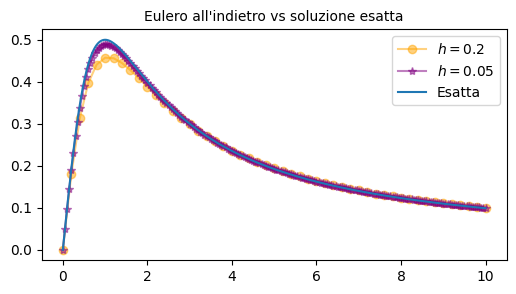

In [9]:
# Es. 3.3 - Eulero all'indietro per h = 0.2, 0.05
# dato iniziale
y0 = 0
# funzione f del problema di cauchy che dipende dal tempo e dalla y
f = lambda t, y: 1.0/(1+t**2) - 2*y*y

t1, u1back = eulero_indietro(f, t0, tN, y0, h = 0.2)
t2, u2back = eulero_indietro(f, t0, tN, y0, h = 0.05)

plt.figure(figsize = (6,3))
plt.plot(t1, u1back, '-o', label = '$h=0.2$', alpha = 0.5, color = 'orange')
plt.plot(t2, u2back, '-*', label = '$h=0.05$', alpha = 0.5, color = 'purple')
plt.plot(tplot, yesatta(tplot), label = 'Esatta')
plt.title("Eulero all'indietro vs soluzione esatta", fontsize = 10)
plt.legend()
plt.show()

<mark>**Esercizio 3.4**</mark></br>
I confronti grafici sono molto utili, ma è altrettanto utile avere un riscontro quantitativo. Per valutare la bontà dell'approssimazione $u_n\approx y(t_n)$ sull'intera griglia temporale, si può calcolare l'errore globale
</br>
\begin{equation*}
e_{h}=\max_{n=0,\dots,N}\;|y(t_{n})-u_{n}|,
\end{equation*}
dove l'errore dipende dal passo scelto $h>0$. Calcolare l'errore globale per i metodi di **Eulero in avanti e all'indietro** quando $h=0.2,0.05$.


In [10]:
# Es. 3.4 - Errori globali a confronto


e1=np.max(np.abs(yesatta(t1)-u1))  # TODO: errore Eulero in avanti (h = 0.2)
e2=np.max(np.abs(yesatta(t2)-u2))  # TODO: errore Eulero in avanti (h = 0.05)

e1back=np.max(np.abs(yesatta(t1)-u1back)) # TODO: errore Eulero all'indietro (h = 0.2)
e2back=np.max(np.abs(yesatta(t2)-u2back)) # TODO: errore Eulero all'indietro (h = 0.05)

print("Metodo\t\tErrore\t\tPassi\n" + "-"*37)
print("EA (h=0.2)\t%.2e\t%d" % (e1, len(t1)-1))
print("EI (h=0.2)\t%.2e\t%d\n" % (e1back, len(t1)-1))
print("EA (h=0.05)\t%.2e\t%d" % (e2, len(t2)-1))
print("EI (h=0.05)\t%.2e\t%d" % (e2back, len(t2)-1))

Metodo		Errore		Passi
-------------------------------------
EA (h=0.2)	5.45e-02	50
EI (h=0.2)	4.68e-02	50

EA (h=0.05)	1.28e-02	200
EI (h=0.05)	1.23e-02	200


In [ ]:
#emerge che gli errori sono confrontabili con i metodi di eulero esplicito e implicito

<mark>**Esercizio 3.5**</mark></br>  Calcolare gli errori $e_{h}$ al variare di $h=0.2, 0.1, 0.05, 0.025, 0.0125$, quindi rappresentarne l'andamento utilizzando un opportuno plot in scala logaritmica. I risultati sono coerenti con la teoria?

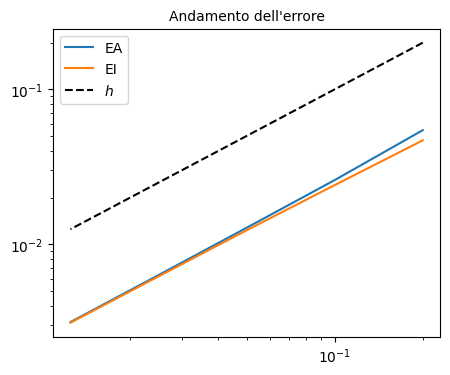

In [11]:
# Es. 3.5 - Ordini di convergenza
# passo h ed errori
hs=[0.2,0.1,0.05,0.025,0.0125] #oppure hs=[] ma nel for devo fare hs.append(0.2/2**h), con h l'indice che viene aggiornato ogni ciclo
errEA, errEI = [], []


# TODO: calcolare errori ad ogni passo h
for h in hs:
    tE,uE=eulero_avanti(f, t0, tN, y0, h)
    tI,uI=eulero_indietro(f, t0, tN, y0, h)

    errEA.append(np.max(np.abs(yesatta(tE)-uE)))
    errEI.append(np.max(np.abs(yesatta(tI)-uI)))


plt.figure(figsize = (5, 4))
plt.loglog(hs, errEA, label = 'EA')
plt.loglog(hs, errEI, label = 'EI')
plt.loglog(hs, hs, '--k', label = '$h$')
plt.legend()
plt.title("Andamento dell'errore", fontsize = 10)
plt.show()

<mark>**Esercizio 3.6**</mark></br>
Risolvere il problema con i metodi di **Eulero in avanti** e di **Eulero all'indietro**, scegliendo un passo $h=1$. Riportare su grafici differenti le soluzioni numeriche ottenute, confrontandole con la soluzione esatta e calcolare gli errori ottenuti. Cosa si osserva?


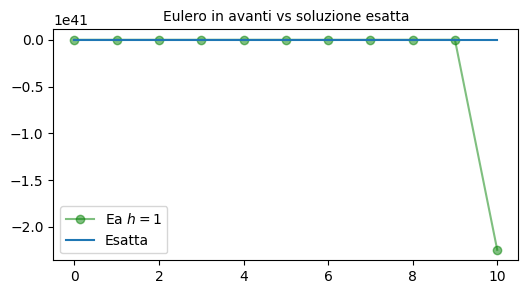

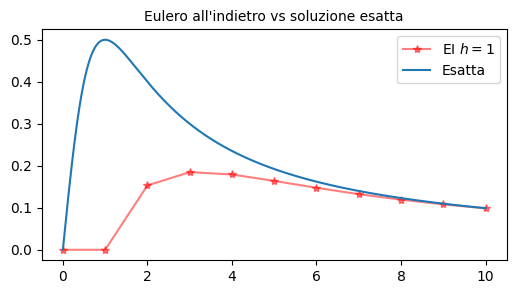

l'errore dell'Eulero in avanti è: 2.246814e+41 
l'errore dell'Eulero all'indietro è: 5.000000e-01 


In [12]:
# Eulero in avanti
tEA, uEA = eulero_avanti(f, t0, tN, y0, h = 1)

plt.figure(num=1, figsize = (6,3))
plt.plot(tEA, uEA, '-o', label = 'Ea $h=1$', alpha = 0.5, color = 'green')
plt.plot(tplot, yesatta(tplot), label = 'Esatta')
plt.title("Eulero in avanti vs soluzione esatta", fontsize = 10)
plt.legend()

# Eulero all'indietro
tEI, uEI = eulero_indietro(f, t0, tN, y0, h = 1)

plt.figure(num=2, figsize = (6,3))
plt.plot(tEI, uEI, '-*', label = 'EI $h=1$', alpha = 0.5, color = 'red')
plt.plot(tplot, yesatta(tplot), label = 'Esatta')
plt.title("Eulero all'indietro vs soluzione esatta", fontsize = 10)
plt.legend()
plt.show()


print("l'errore dell'Eulero in avanti è: %e " %max(abs(yesatta(tEA)-uEA)))
print("l'errore dell'Eulero all'indietro è: %e " %max(abs(yesatta(tEI)-uEI)))


In [ ]:
#NB: anche se l'ordine di convergenza è il medesimo, il metodo di eulero esplicito è CONDIZIONATAMENTE ASSOLUTAMENTE STABILE, dal momento
#che h deve assumere un certo valore, sufficientemente piccolo, mentre il metodo di eulero implicito è INCONDIZIONATAMENTE ASSOLUTAMENTE
#STABILE.

# Esercizi per casa

<mark>**Esercizio 4**</mark></br>
In generale, il metodo di Eulero all'indietro è più oneroso (computazionalmente parlando) rispetto alla sua variante in avanti. In aggiunta, più $h$ è piccolo, e più la simulazione richiede tempo (bisogna fare più passi!). Per quantificare tutto ciò, provare a misurare il tempo d'esecuzione richiesto dai due metodi al variare di $h$.
</br>
</br>
*Hint: potete usare la funzione* $\texttt{perf\_counter}$ *del pacchetto* $\texttt{time}$ *per misurare i tempi d'esecuzione del calcolatore.*


In [13]:
from time import perf_counter
#passo h
hs, timeEA, timeEI= [], [], []
for k in range (5):
    hs.append(0.2/2**k)
    tEA_start=perf_counter()
    th, uh=eulero_avanti(f, t0, tN, y0, hs[-1])
    tEA_stop=perf_counter()
    timeEA.append(tEA_stop-tEA_start)

    tEI_start=perf_counter()
    th, uh=eulero_indietro(f, t0, tN, y0, hs[-1])
    tEI_stop=perf_counter()
    timeEI.append(tEI_stop-tEI_start)

print("time Eulero in avanti\t time Eulero all'indietro")
for i in range (5):
    print(" %e\t\t %e" %(timeEA[i], timeEI[i]))


time Eulero in avanti	 time Eulero all'indietro
 2.342000e-04		 1.562800e-03
 3.427000e-04		 1.664900e-03
 6.707000e-04		 2.562700e-03
 5.935000e-04		 3.406200e-03
 3.720400e-03		 8.762300e-03


<mark>**Esercizio 5**</mark></br>
Un ulteriore metodo *implicito* ad un passo (*one-step*) è il metodo di Crank-Nicolson che possiede il seguente schema iterativo
</br></br>
\begin{equation*}
\begin{cases}
u_{0}=y_{0}\\u_{n+1}=u_{n}+\frac{h}{2}[f(t_{n},u_{n}) +f(t_{n+1},u_{n+1})] & n=0,\dots,N-1.
\end{cases}
\end{equation*}
</br>
A differenza dei metodi di Eulero in avanti e di Eulero all'indietro, che hanno convergenza lineare questo metodo ha un andamento quadratico.

Considerando sempre il problema di Cauchy
</br></br>
\begin{equation*}
\begin{cases}
\displaystyle
y'(t)=\frac{1}{1+t^2}-2y(t)^2 & 0\le t\le 10,\\ y(0)=0,
\end{cases}
\end{equation*}
</br>

la cui soluzione esatta è
\begin{equation*}
y(t)=\frac{t}{1+t^{2}}.
\end{equation*}

Calcolare gli errori </br>
\begin{equation*}
e_{h}=\max_{n=0,\dots,N}\;|y(t_{n})-u_{n}|,
\end{equation*}
al variare di $h=0.2, 0.1, 0.05, 0.025, 0.0125$ e rappresentarne l'andamento utilizzando un opportuno plot in scala logaritmica. I risultati sono coerenti con la teoria?

In [14]:
from utilis_ODE import crank_nicolson

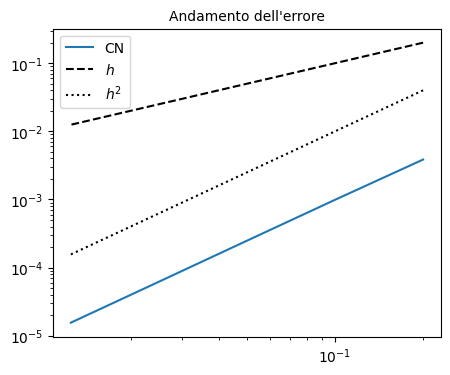

In [16]:
#passo h ed errori
hs, hs2, errCN = [], [], []
t0, tN = 0, 10
f = lambda t, y: 1.0/(1+t**2)-2*y*y
for k in range (5):
    hs.append(0.2/2**k)
    hs2.append((0.2/2**k)**2)
    th, uh = crank_nicolson(f, t0, tN, y0, hs[-1])
    errCN.append(abs(yesatta(th)-uh).max())

plt.figure(figsize=(5, 4))
plt.loglog(hs, errCN, label='CN')

plt.loglog(hs, hs, '--k', label='$h$')
plt.loglog(hs, hs2, ':k', label='$h^2$')
plt.legend()
plt.title("Andamento dell'errore", fontsize=10)
plt.show()

In [ ]:
#la curva che rappresenta l'andamento quadratico risulta parallela a quella dell'errore
#commesso usando il metodo di Crank-Nikolson, pertanto sì, i risultati sono coerenti con
#la teoria.

<mark>**Esercizio 6**</mark></br>
Calcolare il massimo passo $h$ per il seguente problema di Cauchy
\begin{equation*}
\begin{cases}
\displaystyle
y'(t)=-3y(t) & 0\le t\le 1,\\ y(0)=1,
\end{cases}
\end{equation*}
la cui soluzione esatta è
\begin{equation*}
y(t)=e^{-3t}.
\end{equation*}
tale per cui il metodo di Eulero in avanti sia assolutemante stabile.

In [18]:
def calcola_h_stabile (lam, fatt_sicurezza=0.9):
    """
    Calcola il passo h per la stabilità del metodo di Eulero in avanti.
    lam: autovalore (lambda) dell'equazione diff. (deve essere < 0)
    fattore_sicurezza: valore < 1 per garantire stabilità numerica
    """
    if lam >= 0:
        raise ValueError("L'autovalore deve avere parte Reale negativa per la stabilità")
    
    #condizione teorica: h<2/abs(lambda)
    h_max=2.0/abs(lam)
    h_stabile=h_max*fatt_sicurezza

    return h_stabile

#nel caso del problema di cauchy sopra
lam=-3
h_consigliato=calcola_h_stabile(lam)

print(f"Lambda certaco: {lam}")
print(f"h critico (limite): {2.0/abs(lam)}")
print(f"h scelto (con sicurezza): {h_consigliato:.4f}")

Lambda certaco: -3
h critico (limite): 0.6666666666666666
h scelto (con sicurezza): 0.6000
